# SSCC compact multimodal ETL — final resumable pipeline

This Colab notebook continues the private `DesanSilva/sscc-compact-av` dataset from its
frozen 288-sample policy. It keeps 15 medium-load, clean operating conditions across speeds
60, 80, and 100: 144 normal and 144 fault clips, with all four fault types represented.

Each synchronized sample contains recorder audio as lossless FLAC, four vibration channels
anti-aliased from 100 kHz to 25 kHz and stored as compressed float32 NPZ, plus five compact
frames from both iOS and Android video. Five representative sample IDs also retain both
original MP4 files for presentation and loader tests.

Raw archive members exist only in bounded `/content` scratch and are removed after each
verified upload. This notebook performs ETL and format verification; it does not extract
learned representations or train a model.


## 1. Runtime and repository contract

The repository policy is immutable. A rerun verifies its hash, reconstructs the deterministic
selection, discovers completed samples from remote shard metadata, and processes only missing
samples. Four existing base shards are retained as valid checkpoints.


In [2]:
# 1 · Install only the ETL dependencies
%pip install -q numpy pandas pyarrow scipy soundfile pillow huggingface_hub


In [3]:
# 2 · Imports and runtime versions
import hashlib
import io
import json
import platform
import shutil
import subprocess
import tarfile
from datetime import datetime, timezone
from pathlib import Path, PurePosixPath

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
import soundfile as sf
from PIL import Image
from scipy.signal import resample_poly, welch
from google.colab import drive as colab_drive, userdata
from huggingface_hub import CommitOperationAdd, HfApi, HfFileSystem, hf_hub_download, login

if shutil.which("7z") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(["apt-get", "install", "-y", "-qq", "p7zip-full"], check=True)

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pyarrow": pyarrow.__version__,
    "soundfile": sf.__version__,
})


{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.2.3', 'pyarrow': '18.1.0', 'soundfile': '0.14.0'}


In [4]:
# 3 · Fixed endpoint, media policy, and bounded scratch
HF_REPO_ID = "DesanSilva/sscc-compact-av"
EXPECTED_ETL_VERSION = "2.1.0-small15"
EXPECTED_POLICY_HASH = "bf3c00d0367253c360b01042a271d96e618a73b110a6eb39d3b4a0e8ccee004d"

SOURCE_RATE = 100_000
TARGET_RATE = 25_000
AUDIO_DEVICE = "recorder"
VIDEO_DEVICES = ("ios", "android")
VIDEO_FRAMES_PER_CLIP = 5
VIDEO_FRAME_HEIGHT = 256
VIDEO_WEBP_QUALITY = 70
STAGE_BATCH_BYTES = 4 * 1024**3
MIN_FREE_RESERVE_BYTES = 8 * 1024**3
MAX_REMOTE_MEDIA_BYTES = 950 * 1024**2
PRESENTATION_MAX_BYTES = 180 * 1024**2

WORK_ROOT = Path("/content/sscc_final_work")
ARCHIVE_LINK_ROOT = WORK_ROOT / "archive_links"
BASE_STAGE_ROOT = WORK_ROOT / "base_stage"
VIDEO_STAGE_ROOT = WORK_ROOT / "video_stage"
DEMO_STAGE_ROOT = WORK_ROOT / "demo_stage"
LOCAL_SHARD_ROOT = WORK_ROOT / "local_shards"
DRIVE_SOURCE_ROOT = Path("/content/drive/MyDrive/SSCC")

for path in (WORK_ROOT, LOCAL_SHARD_ROOT):
    path.mkdir(parents=True, exist_ok=True)
for path in (BASE_STAGE_ROOT, VIDEO_STAGE_ROOT, DEMO_STAGE_ROOT):
    shutil.rmtree(path, ignore_errors=True)

print("Scratch free GiB:", round(shutil.disk_usage(WORK_ROOT).free / 1024**3, 2))
print("Maximum staged raw batch GiB:", STAGE_BATCH_BYTES / 1024**3)


Scratch free GiB: 87.58
Maximum staged raw batch GiB: 4.0


Mounted at /content/drive


,group,MiB
0,base media,616.025391
4,original video,114.137495
1,compact video,16.279297
3,metadata,0.938656
2,control files,0.055297


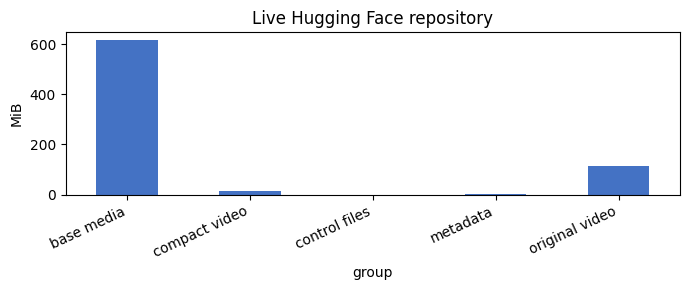

In [5]:
# 4 · Authenticate, verify the private endpoint, and mount Drive shortcuts
HF_TOKEN = userdata.get("HF_TOKEN")
assert HF_TOKEN and HF_TOKEN.startswith("hf_"), "Add a write-capable HF_TOKEN to Colab Secrets."
login(token=HF_TOKEN, add_to_git_credential=False)
hf_api = HfApi(token=HF_TOKEN)
repo_info = hf_api.dataset_info(HF_REPO_ID, files_metadata=True)
assert repo_info.private, "The ETL endpoint must remain private."

colab_drive.mount("/content/drive", force_remount=False)
assert DRIVE_SOURCE_ROOT.exists(), "Add the SSCC folder to My Drive as a shortcut."

remote_files = pd.DataFrame([
    {"path": item.rfilename, "bytes": int(item.size or 0)}
    for item in repo_info.siblings
])
remote_files["group"] = np.select(
    [
        remote_files["path"].str.startswith("shards/"),
        remote_files["path"].str.startswith("video_shards/"),
        remote_files["path"].str.startswith("presentation/"),
        remote_files["path"].str.endswith(".parquet"),
    ],
    ["base media", "compact video", "original video", "metadata"],
    default="control files",
)
remote_status = remote_files.groupby("group", as_index=False)["bytes"].sum()
remote_status["MiB"] = remote_status["bytes"] / 1024**2
display(remote_status[["group", "MiB"]].sort_values("MiB", ascending=False))
ax = remote_status.plot.bar(x="group", y="MiB", legend=False, figsize=(7, 3), color="#4472C4")
ax.set(title="Live Hugging Face repository", ylabel="MiB")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()


### Repository verification

The source inventory, selected manifest, policy, and ETL state are small control artifacts.
They are downloaded before any raw media is touched. The policy hash prevents an accidental
continuation with different sample IDs or media settings.


In [6]:
# 5 · Load metadata only and verify the frozen policy
def download_artifact(filename):
    return Path(hf_hub_download(
        repo_id=HF_REPO_ID,
        filename=filename,
        repo_type="dataset",
        token=HF_TOKEN,
        force_download=True,
    ))

required_artifacts = {
    "source_manifest.parquet", "source_audit.json", "selected_manifest.parquet",
    "sampling_policy.json", "etl_state.json",
}
assert required_artifacts.issubset(set(remote_files["path"]))

source_rows = pd.read_parquet(download_artifact("source_manifest.parquet"))
selected_rows = pd.read_parquet(download_artifact("selected_manifest.parquet"))
source_audit = json.loads(download_artifact("source_audit.json").read_text())
policy = json.loads(download_artifact("sampling_policy.json").read_text())
state = json.loads(download_artifact("etl_state.json").read_text())

sealed_policy = {key: value for key, value in policy.items() if key != "policy_hash"}
computed_hash = hashlib.sha256(
    json.dumps(sealed_policy, sort_keys=True, separators=(",", ":")).encode()
).hexdigest()
assert computed_hash == policy["policy_hash"] == EXPECTED_POLICY_HASH
assert policy["etl_version"] == state["etl_version"] == EXPECTED_ETL_VERSION
assert state["policy_hash"] == EXPECTED_POLICY_HASH
assert len(source_rows) == policy["source_sample_count"] == 6724
assert len(selected_rows) == policy["selected_count"] == 288
assert set(selected_rows["sample_id"]) == set(policy["selected_sample_ids"])
assert source_rows["sample_id"].is_unique and selected_rows["sample_id"].is_unique
print({"source_rows": len(source_rows), "selected_rows": len(selected_rows), "policy_hash": computed_hash})


source_manifest.parquet: reconstructing file:   0%|          |  0.00B /  725kB            

source_manifest.parquet: downloading bytes:           |  0.00B            

selected_manifest.parquet: reconstructing file:   0%|          |  0.00B / 51.3kB            

selected_manifest.parquet: downloading bytes:           |  0.00B            

source_audit.json:   0%|          | 0.00/13.4k [00:00<?, ?B/s]

sampling_policy.json:   0%|          | 0.00/13.9k [00:00<?, ?B/s]

etl_state.json:   0%|          | 0.00/26.2k [00:00<?, ?B/s]

{'source_rows': 6724, 'selected_rows': 288, 'policy_hash': 'bf3c00d0367253c360b01042a271d96e618a73b110a6eb39d3b4a0e8ccee004d'}


## 2. Reproduce and inspect the sampling design

Sampling is synchronized across modalities and approximately evenly spaced within each
operating condition. Normal and fault states are balanced. Fault-classification roles are
balanced within each fault type, while three speeds retain a limited speed-domain shift.
This is a small transfer-learning dataset, not evidence of load or noise generalization.


In [7]:
# 6 · Reproduce the second notebook's deterministic 288-sample selection
source_rows["fd_role"] = np.where(
    source_rows["state"].eq("normal") & source_rows["velocity"].eq(100), "train", "test"
)
source_rows["fc_role"] = np.select(
    [
        source_rows["state"].eq("normal"),
        source_rows["velocity"].eq(80)
        | (source_rows["fault_type"].isin(["dry", "lean"]) & source_rows["velocity"].eq(100)),
    ],
    ["not_applicable", "test"],
    default="train",
)

def choose_spaced_rows(group, count):
    ordered = group.sort_values(["source_index", "sample_id"])
    assert len(ordered) >= count
    positions = np.rint(np.linspace(0, len(ordered) - 1, count)).astype(int)
    return ordered.iloc[positions]

fault_types = ("dry", "lean", "loose", "screwdrop")
speeds = (60, 80, 100)
fault_pool = source_rows.loc[
    source_rows["fault_type"].isin(fault_types)
    & source_rows["load"].eq("med")
    & source_rows["velocity"].isin(speeds)
    & source_rows["noise"].eq("clean")
]
normal_pool = source_rows.loc[
    source_rows["state"].eq("normal")
    & source_rows["load"].eq("med")
    & source_rows["velocity"].isin(speeds)
    & source_rows["noise"].eq("clean")
]

fault_parts = []
for _, group in fault_pool.groupby("source_condition", sort=True):
    fault_type = group["fault_type"].iloc[0]
    role = group["fc_role"].iloc[0]
    larger_group = (
        (fault_type in {"dry", "lean"} and role == "train")
        or (fault_type in {"loose", "screwdrop"} and role == "test")
    )
    fault_parts.append(choose_spaced_rows(group, 18 if larger_group else 9))

normal_parts = [
    choose_spaced_rows(group, 48)
    for _, group in normal_pool.groupby("source_condition", sort=True)
]
reproduced_rows = pd.concat([*fault_parts, *normal_parts], ignore_index=True)
reproduced_rows = reproduced_rows.sort_values("sample_id").reset_index(drop=True)

assert reproduced_rows["sample_id"].tolist() == selected_rows.sort_values("sample_id")["sample_id"].tolist()
assert reproduced_rows.groupby("state").size().to_dict() == {"fault": 144, "normal": 144}
assert reproduced_rows.query("state == 'fault'").groupby("fault_type").size().eq(36).all()
selected_rows = reproduced_rows
print("Selection reproduced exactly:", len(selected_rows), "clips /", selected_rows["source_condition"].nunique(), "conditions")


Selection reproduced exactly: 288 clips / 15 conditions


velocity,60,80,100
class_name,,,
normal,48,48,48
dry,18,9,9
lean,18,9,9
loose,9,18,9
screwdrop,9,18,9


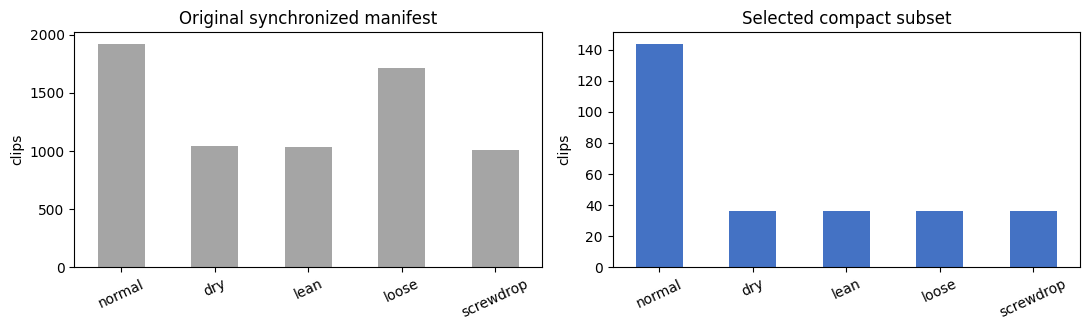

In [8]:
# 7 · Visualize source scope and selected operating coverage
source_classes = source_rows.assign(
    class_name=np.where(source_rows["state"].eq("normal"), "normal", source_rows["fault_type"])
).groupby("class_name").size()
selected_classes = selected_rows.assign(
    class_name=np.where(selected_rows["state"].eq("normal"), "normal", selected_rows["fault_type"])
).groupby("class_name").size()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
source_classes.reindex(["normal", *fault_types]).plot.bar(ax=axes[0], color="#A5A5A5")
axes[0].set(title="Original synchronized manifest", ylabel="clips", xlabel="")
selected_classes.reindex(["normal", *fault_types]).plot.bar(ax=axes[1], color="#4472C4")
axes[1].set(title="Selected compact subset", ylabel="clips", xlabel="")
for axis in axes:
    axis.tick_params(axis="x", rotation=25)
plt.tight_layout()

coverage = selected_rows.assign(
    class_name=np.where(selected_rows["state"].eq("normal"), "normal", selected_rows["fault_type"])
).pivot_table(index="class_name", columns="velocity", values="sample_id", aggfunc="count", fill_value=0)
display(coverage.reindex(["normal", *fault_types]))


fc_role,test,train
fault_type,,
dry,18,18
lean,18,18
loose,18,18
screwdrop,18,18


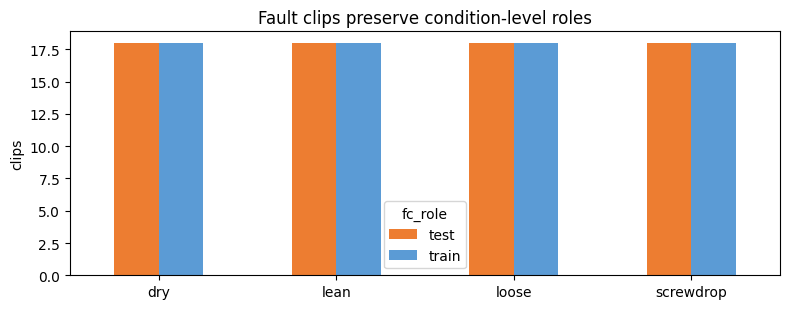

In [9]:
# 8 · Visualize fault-classification role balance
role_counts = (
    selected_rows.query("state == 'fault'")
    .groupby(["fault_type", "fc_role"]).size().unstack(fill_value=0)
    .reindex(fault_types)
)
ax = role_counts.plot.bar(figsize=(8, 3.2), color=["#ED7D31", "#5B9BD5"])
ax.set(title="Fault clips preserve condition-level roles", xlabel="", ylabel="clips")
plt.xticks(rotation=0)
plt.tight_layout()
display(role_counts)


### Why keep shards below 1 GiB?

Sharding is not mathematically required for a compact dataset of this size. A single TAR
would train identically. It is still operationally useful: each verified TAR is a restart
checkpoint, failed uploads repeat less work, and streaming can begin without materializing
the whole dataset. The existing four base TARs total about 617 MiB, so this notebook keeps
them and creates only missing video shards. Repacking them would add download, disk, and
upload cost without improving the samples or representations.


## 3. Mounted multipart archives and bounded staging

Google Drive may expose shortcut-backed split volumes with suffixes such as
`.7z.001.p3wSD5`. Local symlinks restore the exact `.7z.001` sequence expected by 7-Zip.
Only named members for one bounded batch are extracted.


In [10]:
# 9 · Normalize Drive-suffixed split archive names with local symlinks
shutil.rmtree(ARCHIVE_LINK_ROOT, ignore_errors=True)
ARCHIVE_LINK_ROOT.mkdir(parents=True)
archive_paths = {}

for archive in source_audit["archive_sets"]:
    archive_name = archive["archive_name"]
    part_count = int(archive["parts"])
    first_name = f"{archive_name}.001"
    first_matches = [
        path for path in DRIVE_SOURCE_ROOT.rglob(f"{first_name}*")
        if path.name == first_name or path.name.startswith(f"{first_name}.")
    ]
    assert len(first_matches) == 1, (first_name, len(first_matches))
    mounted_dir = first_matches[0].parent
    link_dir = ARCHIVE_LINK_ROOT / archive_name
    link_dir.mkdir()
    for part in range(1, part_count + 1):
        expected = f"{archive_name}.{part:03d}"
        matches = [
            path for path in mounted_dir.glob(f"{expected}*")
            if path.name == expected or path.name.startswith(f"{expected}.")
        ]
        assert len(matches) == 1, (expected, len(matches))
        (link_dir / expected).symlink_to(matches[0])
    archive_paths[archive_name] = link_dir / first_name
    print(archive_name, "parts:", part_count)


SSCC_dataset_abnormal.7z parts: 15
SSCC_dataset_normal.7z parts: 6


In [11]:
# 10 · Resolve archive members and split work into bounded raw batches
def source_reference(row, modality):
    archive_name, member_path = row[f"{modality}_file_id"].split("::", 1)
    member = PurePosixPath(member_path)
    assert not member.is_absolute() and ".." not in member.parts
    return archive_name, member_path

def split_stage_batches(rows, modalities):
    batch_indices = []
    batch_bytes = 0
    for index, row in rows.sort_values("sample_id").iterrows():
        row_bytes = sum(int(row[f"{modality}_size"]) for modality in modalities)
        assert row_bytes <= STAGE_BATCH_BYTES
        if batch_indices and batch_bytes + row_bytes > STAGE_BATCH_BYTES:
            yield rows.loc[batch_indices].sort_values("sample_id")
            batch_indices, batch_bytes = [], 0
        batch_indices.append(index)
        batch_bytes += row_bytes
    if batch_indices:
        yield rows.loc[batch_indices].sort_values("sample_id")

def stage_batch(rows, modalities, stage_root):
    shutil.rmtree(stage_root, ignore_errors=True)
    stage_root.mkdir(parents=True)
    required_bytes = int(rows[[f"{modality}_size" for modality in modalities]].sum().sum())
    assert required_bytes <= STAGE_BATCH_BYTES
    assert shutil.disk_usage(WORK_ROOT).free - required_bytes >= MIN_FREE_RESERVE_BYTES

    references = []
    archive_names = set()
    for _, row in rows.iterrows():
        for modality in modalities:
            archive_name, member_path = source_reference(row, modality)
            archive_names.add(archive_name)
            references.append((row[f"{modality}_file_id"], member_path, int(row[f"{modality}_size"])))
    assert len(archive_names) == 1
    archive_name = next(iter(archive_names))
    member_list = WORK_ROOT / f"{archive_name}.members.txt"
    member_list.write_text("\n".join(member for _, member, _ in references))
    subprocess.run(
        ["7z", "x", "-y", "-bd", "-scsUTF-8", f"-o{stage_root}",
         str(archive_paths[archive_name]), f"@{member_list}"],
        check=True,
    )
    member_list.unlink()

    staged = {}
    for reference, member_path, expected_size in references:
        path = stage_root / member_path
        assert path.exists() and path.stat().st_size == expected_size
        staged[reference] = path
    print({"staged_samples": len(rows), "staged_GiB": round(required_bytes / 1024**3, 3)})
    return staged


In [15]:
# 11 · Strict compact-media helpers
def add_tar_bytes(archive, name, payload):
    info = tarfile.TarInfo(name)
    info.size = len(payload)
    info.mtime = 0
    archive.addfile(info, io.BytesIO(payload))

def encode_and_check_flac(source_path, destination):
    source_audio, source_rate = sf.read(source_path, dtype="float32", always_2d=True)
    assert np.isfinite(source_audio).all()
    assert 4.5 <= len(source_audio) / source_rate <= 5.5
    subprocess.run(
        ["ffmpeg", "-v", "error", "-y", "-i", str(source_path), "-vn",
         "-c:a", "flac", "-compression_level", "8", str(destination)],
        check=True,
    )
    compact_audio, compact_rate = sf.read(destination, dtype="float32", always_2d=True)
    assert source_rate == compact_rate and source_audio.shape == compact_audio.shape
    assert np.allclose(source_audio, compact_audio, atol=1e-7)
    return {
        "sample_rate": int(source_rate),
        "channels": int(source_audio.shape[1]),
        "duration_seconds": float(len(source_audio) / source_rate),
        "clipped_fraction": float(np.mean(np.abs(source_audio) >= 0.999)),
    }

def read_vibration(path):
    frame = pd.read_csv(path, comment="#", header=None, low_memory=False)
    numeric = frame.apply(pd.to_numeric, errors="coerce")
    if numeric.iloc[0].isna().any() and numeric.iloc[1:].notna().all().all():
        numeric = numeric.iloc[1:].reset_index(drop=True)
    assert numeric.shape[1] >= 5
    values = numeric.iloc[:, :5].to_numpy(dtype=np.float64)
    assert np.isfinite(values).all()
    timestamps = values[:, 0]
    deltas = np.diff(timestamps)
    assert np.all(deltas > 0)
    median_delta = float(np.median(deltas))
    inferred_rate = 1.0 / median_delta
    jitter = float(np.max(np.abs(deltas - median_delta)) / median_delta)
    duration = float(timestamps[-1] - timestamps[0] + median_delta)
    assert abs(inferred_rate - SOURCE_RATE) / SOURCE_RATE <= 0.02
    assert jitter <= 0.02 and 4.5 <= duration <= 5.5
    return values[:, 1:5].T, inferred_rate, jitter, duration

def compact_vibration(path):
    source, inferred_rate, jitter, duration = read_vibration(path)
    compact = resample_poly(source, TARGET_RATE, SOURCE_RATE, axis=1).astype(np.float32)
    assert compact.shape[0] == 4 and np.isfinite(compact).all()
    return compact, {
        "rows": int(compact.shape[1]), "channels": 4,
        "inferred_rate": inferred_rate, "output_rate": TARGET_RATE,
        "relative_jitter": jitter, "duration_seconds": duration,
    }

def probe_video(path):
    result = subprocess.run(
        ["ffprobe", "-v", "error", "-select_streams", "v:0",
         "-show_entries", "stream=width,height,r_frame_rate,codec_name:format=duration",
         "-of", "json", str(path)],
        check=True, capture_output=True, text=True,
    )
    payload = json.loads(result.stdout)
    assert len(payload.get("streams", [])) == 1
    stream = payload["streams"][0]
    duration = float(payload["format"]["duration"])
    assert 4.0 <= duration, (path.name, duration)
    return {
        "codec": stream["codec_name"], "width": int(stream["width"]),
        "height": int(stream["height"]), "duration_seconds": duration,
    }

def extract_frames(source_path, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["ffmpeg", "-v", "error", "-y", "-i", str(source_path), "-an",
         "-vf", f"fps=1,scale=-2:{VIDEO_FRAME_HEIGHT}:flags=lanczos",
         "-frames:v", str(VIDEO_FRAMES_PER_CLIP), "-c:v", "libwebp",
         "-quality", str(VIDEO_WEBP_QUALITY), str(output_dir / "frame_%02d.webp")],
        check=True,
    )
    paths = sorted(output_dir.glob("frame_*.webp"))
    assert len(paths) == VIDEO_FRAMES_PER_CLIP
    arrays = [np.asarray(Image.open(path).convert("RGB"), dtype=np.float32) for path in paths]
    assert len({array.shape for array in arrays}) == 1
    diagnostics = {
        "saturated_fraction": float(np.mean([np.mean((a <= 3) | (a >= 252)) for a in arrays])),
        "mean_frame_change": float(np.mean([
            np.mean(np.abs(arrays[i] - arrays[i - 1])) / 255
            for i in range(1, len(arrays))
        ])),
        "shape": list(arrays[0].shape),
    }
    return paths, diagnostics


## 4. One-sample source-to-compact visual check

One synchronized sample is extracted to show the original signals and compact forms. FLAC is
lossless, vibration is anti-aliased before downsampling, and video is represented by sparse
frames from both cameras. These are compact data representations, not learned embeddings.


In [16]:
# 12 · Materialize and compact one representative synchronized sample
demo_row = selected_rows.query("state == 'normal' and velocity == 80").sort_values("source_index").iloc[24]
demo_rows = selected_rows.loc[selected_rows["sample_id"].eq(demo_row["sample_id"])]
demo_staged = stage_batch(demo_rows, ("recorder", "vibration", "ios", "android"), DEMO_STAGE_ROOT)

demo_output = WORK_ROOT / "demo_output"
shutil.rmtree(demo_output, ignore_errors=True)
demo_output.mkdir()
demo_audio_source = demo_staged[demo_row["recorder_file_id"]]
demo_vibration_source = demo_staged[demo_row["vibration_file_id"]]
demo_flac = demo_output / "audio.flac"
demo_audio_qc = encode_and_check_flac(demo_audio_source, demo_flac)
demo_vibration_raw, _, _, _ = read_vibration(demo_vibration_source)
demo_vibration, demo_vibration_qc = compact_vibration(demo_vibration_source)
demo_frames = {}
demo_video_qc = {}
for device in VIDEO_DEVICES:
    video_path = demo_staged[demo_row[f"{device}_file_id"]]
    demo_video_qc[device] = probe_video(video_path)
    demo_frames[device], _ = extract_frames(video_path, demo_output / device)
print(demo_row[["sample_id", "state", "velocity", "source_condition"]].to_dict())


{'staged_samples': 1, 'staged_GiB': 0.066}
{'sample_id': 'normal__med_vel80_clean__0035', 'state': 'normal', 'velocity': 80, 'source_condition': 'normal/med_vel80_clean'}


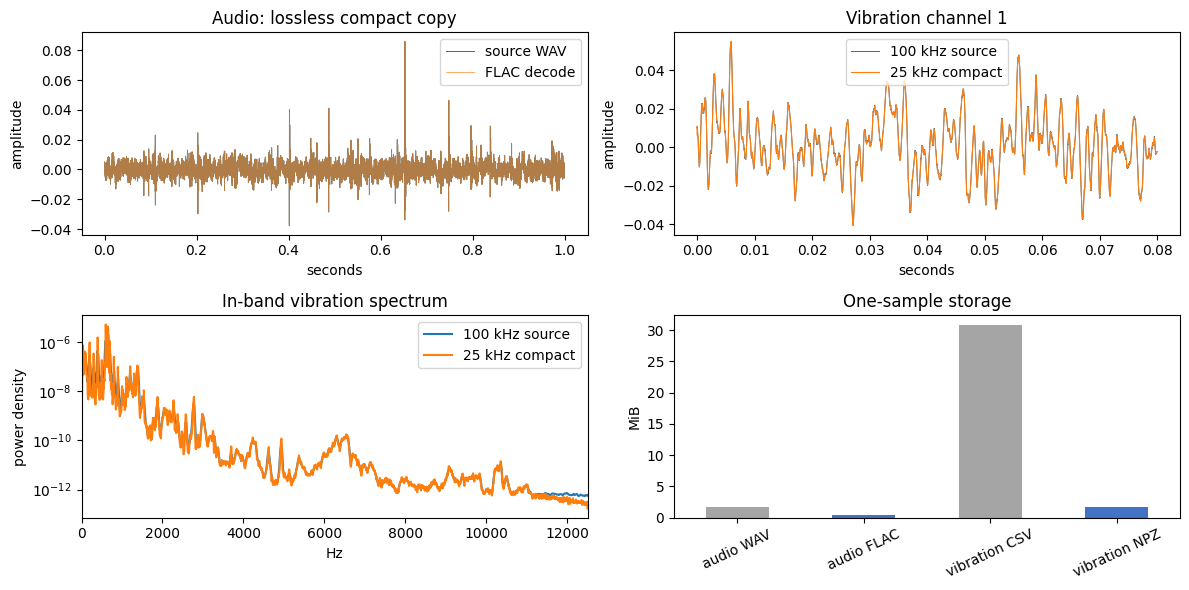

In [17]:
# 13 · Visualize original and compact audio/vibration
original_audio, audio_rate = sf.read(demo_audio_source, dtype="float32", always_2d=True)
compact_audio, compact_audio_rate = sf.read(demo_flac, dtype="float32", always_2d=True)
audio_seconds = np.arange(min(len(original_audio), audio_rate)) / audio_rate

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0, 0].plot(audio_seconds, original_audio[:audio_rate, 0], linewidth=0.7, label="source WAV")
axes[0, 0].plot(audio_seconds, compact_audio[:audio_rate, 0], linewidth=0.7, alpha=0.65, label="FLAC decode")
axes[0, 0].set(title="Audio: lossless compact copy", xlabel="seconds", ylabel="amplitude")
axes[0, 0].legend()

vib_window = int(0.08 * TARGET_RATE)
axes[0, 1].plot(np.arange(vib_window * 4) / SOURCE_RATE,
                demo_vibration_raw[0, :vib_window * 4], linewidth=0.7, label="100 kHz source")
axes[0, 1].plot(np.arange(vib_window) / TARGET_RATE,
                demo_vibration[0, :vib_window], linewidth=0.8, label="25 kHz compact")
axes[0, 1].set(title="Vibration channel 1", xlabel="seconds", ylabel="amplitude")
axes[0, 1].legend()

for signal, rate, label in [
    (demo_vibration_raw[0], SOURCE_RATE, "100 kHz source"),
    (demo_vibration[0], TARGET_RATE, "25 kHz compact"),
]:
    frequencies, power = welch(signal, fs=rate, nperseg=4096)
    axes[1, 0].semilogy(frequencies, power + 1e-20, label=label)
axes[1, 0].set(xlim=(0, TARGET_RATE / 2), title="In-band vibration spectrum",
               xlabel="Hz", ylabel="power density")
axes[1, 0].legend()

compact_sizes = {
    "audio WAV": demo_audio_source.stat().st_size,
    "audio FLAC": demo_flac.stat().st_size,
    "vibration CSV": demo_vibration_source.stat().st_size,
}
vibration_buffer = io.BytesIO()
np.savez_compressed(vibration_buffer, vibration=demo_vibration)
compact_sizes["vibration NPZ"] = len(vibration_buffer.getvalue())
pd.Series(compact_sizes).div(1024**2).plot.bar(ax=axes[1, 1], color=["#A5A5A5", "#4472C4"] * 2)
axes[1, 1].set(title="One-sample storage", ylabel="MiB", xlabel="")
axes[1, 1].tick_params(axis="x", rotation=25)
plt.tight_layout()


,codec,width,height,duration_seconds
ios,h264,1920,1080,5.527
android,h264,1080,1920,13.158


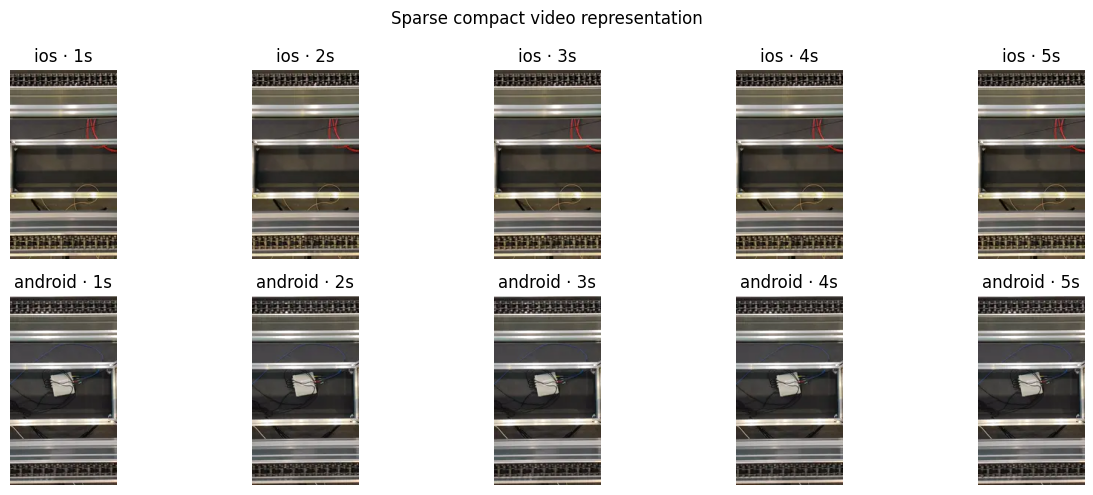

In [18]:
# 14 · Visualize both compact camera views
fig, axes = plt.subplots(2, VIDEO_FRAMES_PER_CLIP, figsize=(13, 5))
for row_index, device in enumerate(VIDEO_DEVICES):
    for frame_index, frame_path in enumerate(demo_frames[device]):
        axes[row_index, frame_index].imshow(Image.open(frame_path))
        axes[row_index, frame_index].axis("off")
        axes[row_index, frame_index].set_title(f"{device} · {frame_index + 1}s")
plt.suptitle("Sparse compact video representation")
plt.tight_layout()
display(pd.DataFrame(demo_video_qc).T)


In [19]:
# 15 · Delete the visual-check source and compact scratch
shutil.rmtree(DEMO_STAGE_ROOT)
shutil.rmtree(demo_output)
del demo_vibration_raw, demo_vibration, original_audio, compact_audio
print("Visual-check scratch deleted.")


Visual-check scratch deleted.


## 5. Recover remote progress

Parquet files paired with listed TARs are the source of truth. ETL state is updated only after
both files have been uploaded and their byte sizes verified. A normal rerun therefore skips
all completed base samples and continues at the first missing video batch.


In [20]:
# 16 · Remote upload, verification, and recovery helpers
def remote_items():
    return {
        item.rfilename: item
        for item in hf_api.dataset_info(HF_REPO_ID, files_metadata=True).siblings
    }

def read_remote_parquet(remote_path):
    return pd.read_parquet(download_artifact(remote_path))

def upload_file(local_path, remote_path):
    hf_api.upload_file(
        path_or_fileobj=str(local_path), path_in_repo=remote_path,
        repo_id=HF_REPO_ID, repo_type="dataset",
    )

def commit_pair(tar_path, tar_remote, metadata_path, metadata_remote):
    hf_api.create_commit(
        repo_id=HF_REPO_ID,
        repo_type="dataset",
        commit_message=f"Add {tar_remote}",
        operations=[
            CommitOperationAdd(path_in_repo=tar_remote, path_or_fileobj=str(tar_path)),
            CommitOperationAdd(path_in_repo=metadata_remote, path_or_fileobj=str(metadata_path)),
        ],
    )
    items = remote_items()
    assert int(items[tar_remote].size or 0) == tar_path.stat().st_size
    assert int(items[metadata_remote].size or 0) == metadata_path.stat().st_size

def recover_completed(metadata_dir, shard_dir):
    items = remote_items()
    completed = set()
    metadata_paths = sorted(
        name for name in items
        if name.startswith(f"{metadata_dir}/") and name.endswith(".parquet")
    )
    for metadata_remote in metadata_paths:
        stem = Path(metadata_remote).stem
        assert f"{shard_dir}/{stem}.tar" in items
        completed.update(read_remote_parquet(metadata_remote)["sample_id"])
    return completed, len(metadata_paths)

state_path = WORK_ROOT / "etl_state.json"

def upload_state():
    state["updated_utc"] = datetime.now(timezone.utc).isoformat()
    state_path.write_text(json.dumps(state, indent=2))
    upload_file(state_path, "etl_state.json")


metadata/base-00000.parquet: reconstructing file:   0%|          |  0.00B / 20.8kB            

metadata/base-00000.parquet: downloading bytes:           |  0.00B            

metadata/base-00001.parquet: reconstructing file:   0%|          |  0.00B / 16.1kB            

metadata/base-00001.parquet: downloading bytes:           |  0.00B            

metadata/base-00002.parquet: reconstructing file:   0%|          |  0.00B / 19.7kB            

...

video_metadata/video-00000.parquet: reconstructing file:   0%|          |  0.00B / 30.6kB            

video_metadata/video-00000.parquet: downloading bytes:           |  0.00B            

video_metadata/video-00001.parquet: reconstructing file:   0%|          |  0.00B / 28.9kB            

video_metadata/video-00001.parquet: downloading bytes:           |  0.00B            

,phase,completed,remaining
0,audio + vibration,288,0
1,two-view sparse video,288,0


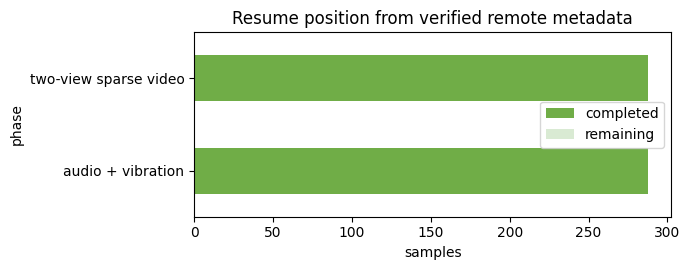

In [21]:
# 17 · Reconcile live progress before conversion
selected_ids = set(selected_rows["sample_id"])
base_completed, base_index = recover_completed("metadata", "shards")
video_completed, video_index = recover_completed("video_metadata", "video_shards")
assert base_completed.issubset(selected_ids)
assert video_completed.issubset(selected_ids)
state["base_completed_sample_ids"] = sorted(base_completed)
state["video_completed_sample_ids"] = sorted(video_completed)

progress = pd.DataFrame({
    "phase": ["audio + vibration", "two-view sparse video"],
    "completed": [len(base_completed), len(video_completed)],
    "remaining": [len(selected_ids - base_completed), len(selected_ids - video_completed)],
})
display(progress)
progress.set_index("phase")[["completed", "remaining"]].plot.barh(
    stacked=True, figsize=(7, 2.8), color=["#70AD47", "#D9EAD3"]
)
plt.xlabel("samples")
plt.title("Resume position from verified remote metadata")
plt.tight_layout()


## 6. Audio and vibration shards

The current repository already contains this phase. On rerun, the loop is empty. If any
verified base sample is missing, only its archive members are staged, converted, uploaded,
checked, and then deleted.


In [22]:
# 18 · Build one compact audio-vibration TAR
def build_base_shard(rows, staged, tar_path, metadata_path):
    records = []
    current_root = WORK_ROOT / "current_base"
    with tarfile.open(tar_path, "w") as archive:
        for _, row in rows.iterrows():
            sample_dir = current_root / row["sample_id"]
            shutil.rmtree(sample_dir, ignore_errors=True)
            sample_dir.mkdir(parents=True)
            flac_path = sample_dir / "audio.flac"
            audio_qc = encode_and_check_flac(staged[row["recorder_file_id"]], flac_path)
            vibration, vibration_qc = compact_vibration(staged[row["vibration_file_id"]])
            vibration_buffer = io.BytesIO()
            np.savez_compressed(vibration_buffer, vibration=vibration)
            audio_payload = flac_path.read_bytes()
            vibration_payload = vibration_buffer.getvalue()
            metadata = {
                "sample_id": row["sample_id"], "source_condition": row["source_condition"],
                "state": row["state"], "fault_type": row["fault_type"], "load": row["load"],
                "velocity": int(row["velocity"]), "noise": row["noise"],
                "source_index": row["source_index"], "fd_role": row["fd_role"],
                "fc_role": row["fc_role"], "audio_device": AUDIO_DEVICE,
                "audio_qc": audio_qc, "vibration_qc": vibration_qc,
                "vibration_rate": TARGET_RATE, "vibration_channels": 4,
                "source_references": {
                    "recorder": row["recorder_file_id"],
                    "vibration": row["vibration_file_id"],
                },
                "policy_hash": EXPECTED_POLICY_HASH, "etl_version": EXPECTED_ETL_VERSION,
            }
            metadata_payload = json.dumps(metadata, sort_keys=True).encode()
            add_tar_bytes(archive, f"{row['sample_id']}.audio.flac", audio_payload)
            add_tar_bytes(archive, f"{row['sample_id']}.vib.npz", vibration_payload)
            add_tar_bytes(archive, f"{row['sample_id']}.json", metadata_payload)
            records.append({
                **metadata,
                "audio_qc": json.dumps(audio_qc),
                "vibration_qc": json.dumps(vibration_qc),
                "audio_bytes": len(audio_payload),
                "vibration_bytes": len(vibration_payload),
                "metadata_bytes": len(metadata_payload),
            })
            shutil.rmtree(sample_dir)
    pd.DataFrame(records).to_parquet(metadata_path, index=False)


In [23]:
# 19 · Process every missing base batch in one Run all pass
for archive_name in sorted(archive_paths):
    archive_mask = selected_rows["recorder_file_id"].str.startswith(f"{archive_name}::")
    pending_rows = selected_rows.loc[archive_mask & ~selected_rows["sample_id"].isin(base_completed)]
    for batch_rows in split_stage_batches(pending_rows, ("recorder", "vibration")):
        staged = stage_batch(batch_rows, ("recorder", "vibration"), BASE_STAGE_ROOT)
        stem = f"base-{base_index:05d}"
        tar_path = LOCAL_SHARD_ROOT / f"{stem}.tar"
        metadata_path = LOCAL_SHARD_ROOT / f"{stem}.parquet"
        build_base_shard(batch_rows, staged, tar_path, metadata_path)
        commit_pair(tar_path, f"shards/{stem}.tar", metadata_path, f"metadata/{stem}.parquet")
        base_completed.update(batch_rows["sample_id"])
        state["base_completed_sample_ids"] = sorted(base_completed)
        upload_state()
        shutil.rmtree(BASE_STAGE_ROOT)
        tar_path.unlink()
        metadata_path.unlink()
        print({"base_completed": len(base_completed), "total": len(selected_rows), "shard": stem})
        base_index += 1

assert base_completed == selected_ids


## 7. Two-view compact video and presentation originals

Each selected sample stores five 256-pixel-high WebP frames per phone. This retains both
viewpoints at low storage cost. Original MP4s are limited to one normal sample and one sample
per fault type; they are presentation/test assets, not duplicated training examples.


In [24]:
# 20 · Build one sparse two-view video TAR
def build_video_shard(rows, staged, tar_path, metadata_path):
    records = []
    current_root = WORK_ROOT / "current_video"
    with tarfile.open(tar_path, "w") as archive:
        for _, row in rows.iterrows():
            sample_dir = current_root / row["sample_id"]
            shutil.rmtree(sample_dir, ignore_errors=True)
            sample_dir.mkdir(parents=True)
            probes, diagnostics = {}, {}
            frame_bytes = 0
            for device in VIDEO_DEVICES:
                source_path = staged[row[f"{device}_file_id"]]
                probes[device] = probe_video(source_path)
                frame_paths, diagnostics[device] = extract_frames(source_path, sample_dir / device)
                for frame_index, frame_path in enumerate(frame_paths):
                    payload = frame_path.read_bytes()
                    frame_bytes += len(payload)
                    add_tar_bytes(
                        archive,
                        f"{row['sample_id']}.{device}.frame_{frame_index:02d}.webp",
                        payload,
                    )
            metadata = {
                "sample_id": row["sample_id"], "source_condition": row["source_condition"],
                "state": row["state"], "fault_type": row["fault_type"], "load": row["load"],
                "velocity": int(row["velocity"]), "noise": row["noise"],
                "fd_role": row["fd_role"], "fc_role": row["fc_role"],
                "video_devices": list(VIDEO_DEVICES), "source_video_probe": probes,
                "source_references": {
                    device: row[f"{device}_file_id"] for device in VIDEO_DEVICES
                },
                "frame_diagnostics": diagnostics, "policy_hash": EXPECTED_POLICY_HASH,
                "etl_version": EXPECTED_ETL_VERSION,
            }
            metadata_payload = json.dumps(metadata, sort_keys=True).encode()
            add_tar_bytes(archive, f"{row['sample_id']}.video.json", metadata_payload)
            records.append({
                **metadata,
                "source_video_probe": json.dumps(probes),
                "frame_diagnostics": json.dumps(diagnostics),
                "frame_bytes": frame_bytes,
                "metadata_bytes": len(metadata_payload),
            })
            shutil.rmtree(sample_dir)
    pd.DataFrame(records).to_parquet(metadata_path, index=False)


In [25]:
# 21 · Process every missing compact-video batch in the same Run all pass
for archive_name in sorted(archive_paths):
    archive_mask = selected_rows["ios_file_id"].str.startswith(f"{archive_name}::")
    pending_rows = selected_rows.loc[archive_mask & ~selected_rows["sample_id"].isin(video_completed)]
    for batch_rows in split_stage_batches(pending_rows, VIDEO_DEVICES):
        staged = stage_batch(batch_rows, VIDEO_DEVICES, VIDEO_STAGE_ROOT)
        stem = f"video-{video_index:05d}"
        tar_path = LOCAL_SHARD_ROOT / f"{stem}.tar"
        metadata_path = LOCAL_SHARD_ROOT / f"{stem}.parquet"
        build_video_shard(batch_rows, staged, tar_path, metadata_path)
        commit_pair(
            tar_path, f"video_shards/{stem}.tar",
            metadata_path, f"video_metadata/{stem}.parquet",
        )
        video_completed.update(batch_rows["sample_id"])
        state["video_completed_sample_ids"] = sorted(video_completed)
        upload_state()
        shutil.rmtree(VIDEO_STAGE_ROOT)
        tar_path.unlink()
        metadata_path.unlink()
        print({"video_completed": len(video_completed), "total": len(selected_rows), "shard": stem})
        video_index += 1

assert video_completed == selected_ids


In [26]:
# 22 · Upload five paired original-video presentation examples
presentation_pool = selected_rows.loc[
    selected_rows["noise"].eq("clean")
    & (
        ((selected_rows["state"] == "normal") & (selected_rows["fd_role"] == "test"))
        | ((selected_rows["state"] == "fault") & (selected_rows["fc_role"] == "test"))
    )
]
presentation_rows = pd.concat([
    choose_spaced_rows(group, 1)
    for _, group in presentation_pool.groupby("fault_type", sort=True)
]).sort_values("fault_type").reset_index(drop=True)
assert set(presentation_rows["fault_type"]) == {"normal", *fault_types}
assert int(presentation_rows[["ios_size", "android_size"]].sum().sum()) <= PRESENTATION_MAX_BYTES

for archive_name in sorted(archive_paths):
    archive_mask = presentation_rows["ios_file_id"].str.startswith(f"{archive_name}::")
    archive_rows = presentation_rows.loc[archive_mask]
    existing = remote_items()
    pending_rows = archive_rows.loc[archive_rows.apply(
        lambda row: any(
            f"presentation/{row['sample_id']}.{device}.original.mp4" not in existing
            for device in VIDEO_DEVICES
        ),
        axis=1,
    )]
    if pending_rows.empty:
        continue
    staged = stage_batch(pending_rows, VIDEO_DEVICES, VIDEO_STAGE_ROOT)
    operations = []
    for _, row in pending_rows.iterrows():
        for device in VIDEO_DEVICES:
            source_path = staged[row[f"{device}_file_id"]]
            probe_video(source_path)
            operations.append(CommitOperationAdd(
                path_in_repo=f"presentation/{row['sample_id']}.{device}.original.mp4",
                path_or_fileobj=str(source_path),
            ))
    hf_api.create_commit(
        repo_id=HF_REPO_ID, repo_type="dataset",
        commit_message="Add paired presentation originals", operations=operations,
    )
    shutil.rmtree(VIDEO_STAGE_ROOT)

print("Presentation sample IDs:", presentation_rows["sample_id"].tolist())


Presentation sample IDs: ['abnormal__dry__med_vel100_clean_dry__0001', 'abnormal__lean__med_vel100_clean_lean__0001', 'abnormal__loose__med_vel80_clean_loose__0001', 'normal__med_vel60_clean__0001', 'abnormal__screwdrop__med_vel80_clean_screwdrop__0001']


## 8. Final reconciliation and remote-only smoke test

Final metadata is assembled from the per-shard indexes already stored on Hugging Face. The
audit requires every selected ID exactly once in each compact media branch and ten original
presentation MP4s. The smoke test streams TAR members directly from the repository.


In [27]:
# 23 · Reconcile remote outputs and publish final metadata
base_completed, _ = recover_completed("metadata", "shards")
video_completed, _ = recover_completed("video_metadata", "video_shards")
assert base_completed == selected_ids
assert video_completed == selected_ids

items = remote_items()
base_metadata_paths = sorted(
    name for name in items if name.startswith("metadata/") and name.endswith(".parquet")
)
video_metadata_paths = sorted(
    name for name in items if name.startswith("video_metadata/") and name.endswith(".parquet")
)
base_metadata = pd.concat([read_remote_parquet(path) for path in base_metadata_paths], ignore_index=True)
video_metadata = pd.concat([read_remote_parquet(path) for path in video_metadata_paths], ignore_index=True)
assert base_metadata["sample_id"].is_unique and set(base_metadata["sample_id"]) == selected_ids
assert video_metadata["sample_id"].is_unique and set(video_metadata["sample_id"]) == selected_ids

base_manifest = pd.DataFrame([
    {"remote_path": name, "remote_size": int(item.size or 0)}
    for name, item in items.items()
    if name.startswith("shards/") and name.endswith(".tar")
]).sort_values("remote_path")
video_manifest = pd.DataFrame([
    {"remote_path": name, "remote_size": int(item.size or 0)}
    for name, item in items.items()
    if name.startswith("video_shards/") and name.endswith(".tar")
]).sort_values("remote_path")
presentation_names = sorted(
    name for name in items if name.startswith("presentation/") and name.endswith(".mp4")
)
assert len(presentation_names) == 10

presentation_bytes = sum(int(items[name].size or 0) for name in presentation_names)
total_media_bytes = (
    int(base_manifest["remote_size"].sum())
    + int(video_manifest["remote_size"].sum())
    + presentation_bytes
)
assert total_media_bytes <= MAX_REMOTE_MEDIA_BYTES

artifacts = {
    "metadata.parquet": base_metadata.sort_values("sample_id"),
    "video_metadata.parquet": video_metadata.sort_values("sample_id"),
    "shard_manifest.parquet": base_manifest,
    "video_shard_manifest.parquet": video_manifest,
}
for filename, frame in artifacts.items():
    path = WORK_ROOT / filename
    frame.to_parquet(path, index=False)
    upload_file(path, filename)

summary = {
    "etl_version": EXPECTED_ETL_VERSION,
    "policy_hash": EXPECTED_POLICY_HASH,
    "source_count_discovered": int(len(source_rows)),
    "public_count_discrepancy": "authoritative archive manifest has 6724 rows; public headline states 6669",
    "selected_count": int(len(selected_rows)),
    "condition_count": int(selected_rows["source_condition"].nunique()),
    "normal_count": int(selected_rows["state"].eq("normal").sum()),
    "fault_count": int(selected_rows["state"].eq("fault").sum()),
    "audio_device": AUDIO_DEVICE,
    "vibration_channels": 4,
    "vibration_source_rate": SOURCE_RATE,
    "vibration_output_rate": TARGET_RATE,
    "video_devices": list(VIDEO_DEVICES),
    "base_shards": len(base_manifest),
    "video_shards": len(video_manifest),
    "presentation_original_count": len(presentation_names),
    "base_shard_bytes": int(base_manifest["remote_size"].sum()),
    "video_shard_bytes": int(video_manifest["remote_size"].sum()),
    "presentation_bytes": presentation_bytes,
    "total_remote_media_bytes": total_media_bytes,
    "failed_count": 0,
    "duplicate_count": 0,
    "license": "CC BY 4.0",
    "training_scope": "pretrained/frozen modality encoders with a small regularized fusion head",
}
summary_path = WORK_ROOT / "etl_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
upload_file(summary_path, "etl_summary.json")

card = f'''---
license: cc-by-4.0
task_categories:
- audio-classification
- time-series-classification
---
# SSCC compact balanced multimodal subset

This private derived dataset contains 288 synchronized SSCC clips from 15 medium-load,
clean operating conditions at speeds 60, 80, and 100. It retains recorder FLAC audio,
four anti-aliased 25 kHz vibration channels in compressed float32 NPZ, and five sparse frames
from both iOS and Android videos. Five sample IDs retain both unchanged source MP4s for
presentation and loader tests.

The subset is balanced between normal and fault states and balances fault-classification
train/test roles per fault. It is intended for transfer learning or frozen representations,
not training three deep encoders from scratch. It tests speed-domain transfer only; broader
load and noise generalization require additional operating conditions.

The saved development pilot favored recorder-only audio for size and simplicity. The 25 kHz
vibration choice is a size-driven research compromise: its grouped pilot metric was 0.716,
but it did not pass the original strict 99% spectral-energy criterion. Retain this limitation
when interpreting models.

Source: https://yucongzh.github.io/SSCC-Dataset/ (CC BY 4.0).
Policy hash: `{EXPECTED_POLICY_HASH}`.
'''
card_path = WORK_ROOT / "README.md"
card_path.write_text(card)
upload_file(card_path, "README.md")
display(pd.Series(summary))


metadata/base-00000.parquet: reconstructing file:   0%|          |  0.00B / 20.8kB            

metadata/base-00000.parquet: downloading bytes:           |  0.00B            

metadata/base-00001.parquet: reconstructing file:   0%|          |  0.00B / 16.1kB            

metadata/base-00001.parquet: downloading bytes:           |  0.00B            

metadata/base-00002.parquet: reconstructing file:   0%|          |  0.00B / 19.7kB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...eo_shard_manifest.parquet: 100%|##########| 1.85kB / 1.85kB            

No files have been modified since last commit. Skipping to prevent empty commit.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/hf_api.py:11691: UserWarning: Warnings while validating metadata in README.md:
- The task_categories "time-series-classification" is not in the official list: text-classification, token-classification, table-question-answering, question-answering, zero-shot-classification, translation, summarization, feature-extraction, text-generation, fill-mask, sentence-similarity, text-to-speech, text-to-audio, automatic-speech-recognition, audio-to-audio, audio-classification, audio-text-to-text, voice-activity-detection, depth-estimation, image-classification, object-detection, image-segmentation, text-to-image, image-to-text, image-to-image, image-to-video, unconditional-image-generation, video-classification, reinforcement-learning, robotics, tabular-classification, tabular-regression, tabular-to-text, table-to-text, multiple-choice, text-ranking, text-retriev

,0
etl_version,2.1.0-small15
policy_hash,bf3c00d0367253c360b01042a271d96e618a73b110a6eb...
source_count_discovered,6724
public_count_discrepancy,authoritative archive manifest has 6724 rows; ...
selected_count,288
condition_count,15
normal_count,144
fault_count,144
audio_device,recorder
vibration_channels,4


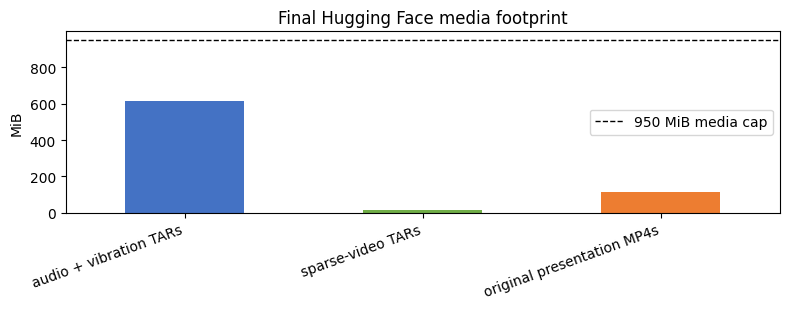

In [28]:
# 24 · Visualize the final remote storage composition
storage = pd.Series({
    "audio + vibration TARs": summary["base_shard_bytes"],
    "sparse-video TARs": summary["video_shard_bytes"],
    "original presentation MP4s": summary["presentation_bytes"],
}).div(1024**2)
ax = storage.plot.bar(figsize=(8, 3.2), color=["#4472C4", "#70AD47", "#ED7D31"])
ax.axhline(MAX_REMOTE_MEDIA_BYTES / 1024**2, color="black", linestyle="--", linewidth=1,
           label="950 MiB media cap")
ax.set(title="Final Hugging Face media footprint", ylabel="MiB", xlabel="")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()


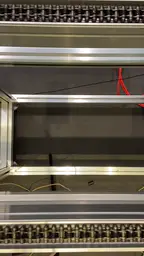

{'base_sample': 'abnormal__dry__med_vel100_clean_dry__0001', 'audio_rate': 44100, 'vibration_shape': (4, 125000), 'video_frame_size': (144, 256), 'remote_stream_test': 'passed'}


In [29]:
# 25 · Stream and decode one base sample and one compact-video sample remotely
hf_fs = HfFileSystem(token=HF_TOKEN)
hf_fs.invalidate_cache()

first_base_shard = base_manifest["remote_path"].iloc[0]
base_payloads = {}
with hf_fs.open(f"datasets/{HF_REPO_ID}/{first_base_shard}", "rb") as remote_file:
    with tarfile.open(fileobj=remote_file, mode="r|*") as archive:
        for member in archive:
            if member.isfile():
                base_payloads[member.name] = archive.extractfile(member).read()
            if len(base_payloads) == 3:
                break
audio_name = next(name for name in base_payloads if name.endswith(".audio.flac"))
vibration_name = next(name for name in base_payloads if name.endswith(".vib.npz"))
metadata_name = next(name for name in base_payloads if name.endswith(".json"))
streamed_audio, streamed_rate = sf.read(io.BytesIO(base_payloads[audio_name]), dtype="float32")
streamed_vibration = np.load(io.BytesIO(base_payloads[vibration_name]))["vibration"]
streamed_metadata = json.loads(base_payloads[metadata_name])
assert np.isfinite(streamed_audio).all()
assert streamed_vibration.dtype == np.float32 and streamed_vibration.shape[0] == 4
assert np.isfinite(streamed_vibration).all()
assert streamed_metadata["sample_id"] == audio_name.removesuffix(".audio.flac")

first_video_shard = video_manifest["remote_path"].iloc[0]
first_frame = None
with hf_fs.open(f"datasets/{HF_REPO_ID}/{first_video_shard}", "rb") as remote_file:
    with tarfile.open(fileobj=remote_file, mode="r|*") as archive:
        for member in archive:
            if member.isfile() and member.name.endswith(".webp"):
                first_frame = Image.open(io.BytesIO(archive.extractfile(member).read())).convert("RGB")
                break
assert first_frame is not None and min(first_frame.size) > 0
display(first_frame)
print({
    "base_sample": streamed_metadata["sample_id"],
    "audio_rate": streamed_rate,
    "vibration_shape": streamed_vibration.shape,
    "video_frame_size": first_frame.size,
    "remote_stream_test": "passed",
})


In [30]:
# 26 · Delete all remaining Colab scratch and print the modelling contract
assert WORK_ROOT == Path("/content/sscc_final_work")
shutil.rmtree(WORK_ROOT)
assert not WORK_ROOT.exists()

print({
    "repository": HF_REPO_ID,
    "samples": 288,
    "conditions": 15,
    "states": ["normal", "fault"],
    "audio": "recorder FLAC",
    "vibration": "four channels, 25 kHz, float32 NPZ",
    "video": "five frames from both iOS and Android",
    "representations": "extract downstream; no learned embeddings are stored here",
    "recommended_training": "frozen pretrained encoders plus a small regularized fusion head",
    "scratch_cleanup": "complete",
})


{'repository': 'DesanSilva/sscc-compact-av', 'samples': 288, 'conditions': 15, 'states': ['normal', 'fault'], 'audio': 'recorder FLAC', 'vibration': 'four channels, 25 kHz, float32 NPZ', 'video': 'five frames from both iOS and Android', 'representations': 'extract downstream; no learned embeddings are stored here', 'recommended_training': 'frozen pretrained encoders plus a small regularized fusion head', 'scratch_cleanup': 'complete'}
